# Importações

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.preprocessing import OneHotEncoder

In [48]:
df_airports = pd.read_csv('../data/raw/airports.csv')
df_airports_id_numerico = pd.read_csv('../data/raw/T_MASTER_CORD.csv')
df_airlines = pd.read_csv('../data/raw/airlines.csv')
df_flights = pd.read_csv('../data/raw/flights.csv')

C:\Users\Pichau\AppData\Local\Temp\ipykernel_1884\993589427.py:4: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv('../data/raw/flights.csv')


# Estatisticas descritivas

## Tabela AIRLINES

In [49]:
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [50]:
print(f'------------------------------ ANALISE TABELA AIRLINES ------------------------------')
print(f'{df_airlines.info()}\n')
print(f'Número de linhas e colunas: {df_airlines.shape}\n')
print(f'Valores nulos: \n{df_airlines.isnull().sum()} \n')
print(f'Contagem de cada valor: \n{df_airlines.value_counts()}')
print(f'Valores duplicados: {df_airlines.duplicated().sum()}\n')
print(f'Valores únicos: \n{df_airlines.nunique()}\n')
print(f'Descrição estatística: \n{df_airlines.describe()}')

------------------------------ ANALISE TABELA AIRLINES ------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IATA_CODE  14 non-null     str  
 1   AIRLINE    14 non-null     str  
dtypes: str(2)
memory usage: 669.0 bytes
None

Número de linhas e colunas: (14, 2)

Valores nulos: 
IATA_CODE    0
AIRLINE      0
dtype: int64 

Contagem de cada valor: 
IATA_CODE  AIRLINE                     
UA         United Air Lines Inc.           1
AA         American Airlines Inc.          1
US         US Airways Inc.                 1
F9         Frontier Airlines Inc.          1
B6         JetBlue Airways                 1
OO         Skywest Airlines Inc.           1
AS         Alaska Airlines Inc.            1
NK         Spirit Air Lines                1
WN         Southwest Airlines Co.          1
DL         Delta Air Lines Inc.            1
EV         

| Não há necessidade de tratamento na tabela 

### Salvando novo dataframe

In [51]:
df_airlines.to_csv('../data/processed/airlines_ajustado.csv', index=False)

## Tabela Airports

In [52]:
df_airports = pd.concat([df_airports, df_airports_id_numerico], ignore_index=True)

In [53]:
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [54]:
print(f'------------------------------ ANALISE TABELA AIRPORTS ------------------------------')
print(f'{df_airports.info()}\n')
print(f'Número de linhas e colunas: {df_airports.shape}\n')
print(f'Valores nulos: \n{df_airports.isnull().sum()} \n')
print(f'Valores duplicados: {df_airports.duplicated().sum()}\n')
print(f'Valores únicos: \n{df_airports.nunique()}\n')
print(f'Descrição estatística: \n{df_airports.describe()}')

------------------------------ ANALISE TABELA AIRPORTS ------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7191 entries, 0 to 7190
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  7191 non-null   object 
 1   AIRPORT    7191 non-null   str    
 2   CITY       7191 non-null   str    
 3   STATE      322 non-null    str    
 4   COUNTRY    7159 non-null   str    
 5   LATITUDE   7187 non-null   float64
 6   LONGITUDE  7187 non-null   float64
dtypes: float64(2), object(1), str(4)
memory usage: 598.8+ KB
None

Número de linhas e colunas: (7191, 7)

Valores nulos: 
IATA_CODE       0
AIRPORT         0
CITY            0
STATE        6869
COUNTRY        32
LATITUDE        4
LONGITUDE       4
dtype: int64 

Valores duplicados: 0

Valores únicos: 
IATA_CODE    7191
AIRPORT      7079
CITY         5940
STATE          54
COUNTRY       227
LATITUDE     7008
LONGITUDE    7101
dtype: int64

Descrição estat

| Foi Verificado valores nulos tanto na latitude quanto na longitude

### Verificando impacto

In [55]:
df_airports_nulos = df_airports.query('LATITUDE.isnull()')

In [56]:
quantidade_de_voos_sem_coord = df_flights[
    df_flights['ORIGIN_AIRPORT'].isin(df_airports_nulos['IATA_CODE'])
].shape[0]
percentual_de_voos_sem_coord = df_flights['ORIGIN_AIRPORT'].isin(
    df_airports_nulos['IATA_CODE']
).mean()

print(f'Quantidade de voos sem coordenadas: {quantidade_de_voos_sem_coord} de {df_flights.shape[0]} voos \nPercentual: {percentual_de_voos_sem_coord:.2%}')    

Quantidade de voos sem coordenadas: 4605 de 5819079 voos 
Percentual: 0.08%


| A quantidade de voos com esses aeroportos é menos de 1%, sendo assim irei apenas remove-los do dataset, já que a qualidade de dados é mais importante que a quantidade e o volume dos ausentes é bem pequeno.

OBS: Valores de altitute e longitude são quase como valores categoricos, ou seja não faz muito sentido aplicar técnica de preenchimento, seja por média, valor acima, valor abaixo etc

### Retirando aeroportos sem coordenadas

In [57]:
df_airports_nulos

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
96,ECP,Northwest Florida Beaches International Airport,Panama City,FL,USA,NaN,NaN
234,PBG,Plattsburgh International Airport,Plattsburgh,NY,USA,NaN,NaN
313,UST,Northeast Florida Regional Airport (St. August...,St. Augustine,FL,USA,NaN,NaN
7190,99999,Unknown Point in Alaska,Unknown Point in Alaska,NaN,US,NaN,NaN


In [58]:
df_airports_ajustado = df_airports[~df_airports['IATA_CODE'].isin(df_airports_nulos['IATA_CODE'])]

### Salvando novo dataframe

In [59]:
df_airports_ajustado.to_csv('../data/processed/airports_ajustado.csv', index=False)

## Tabela Flights

In [60]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
print(f'------------------------------ Analise TABELA FLIGHTS ------------------------------')
print(f'{df_flights.info()}\n')
print(f'Número de linhas e colunas: {df_flights.shape}\n')
print(f'Valores nulos: \n{df_flights.isnull().sum()} \n')
print(f'Valores duplicados: {df_flights.duplicated().sum()}\n')

------------------------------ Analise TABELA FLIGHTS ------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float

| Será necessario tratar os valores nulos

### Tratando valores ausentes

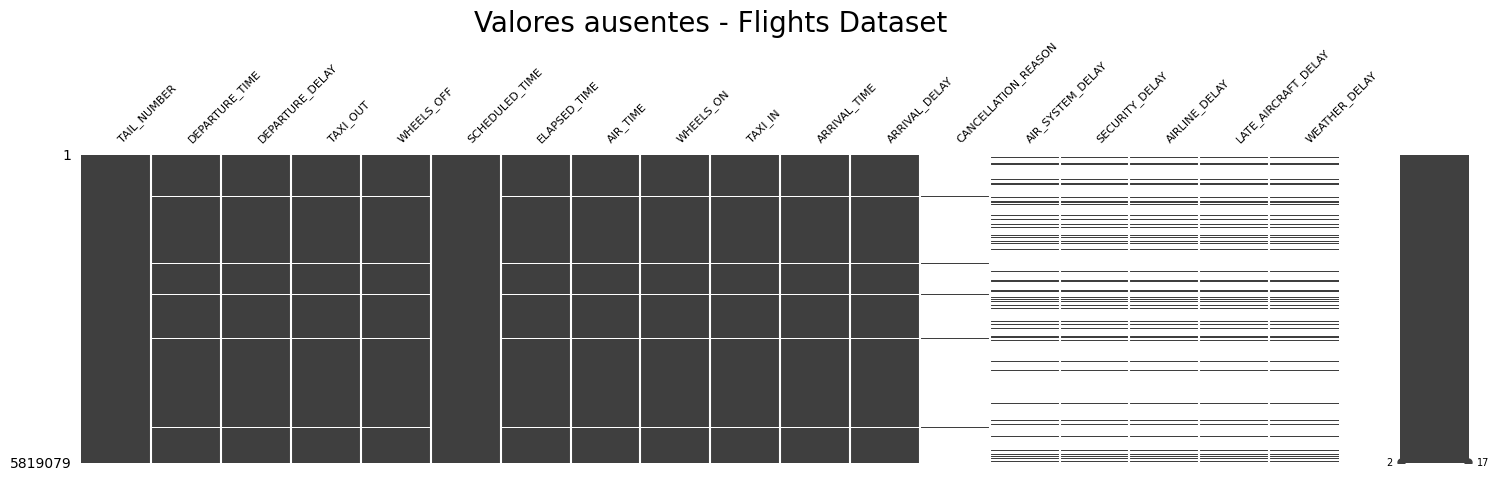

In [62]:
cols_nulos = (
    df_flights.isnull()
    .sum()
)

cols_nulos = cols_nulos[cols_nulos > 0].index
ax = msno.matrix(
        df_flights[cols_nulos], 
        figsize=(18,4),
        fontsize=8
    )
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Valores ausentes - Flights Dataset', fontsize=20)
plt.show()

Analisando apenas os voos não cancelados:

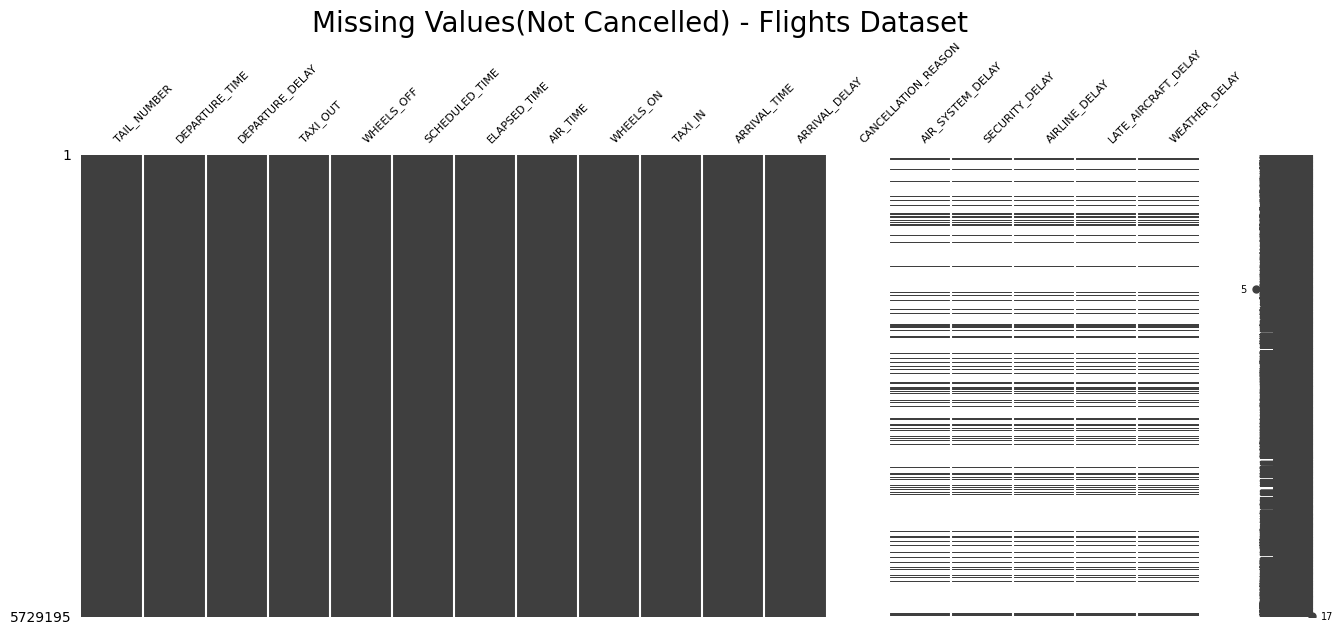

In [63]:
df_not_cancelled = df_flights[df_flights['CANCELLED'] == 0]
ax = msno.matrix(df_not_cancelled[cols_nulos], figsize=(16,6), fontsize=8)
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Missing Values(Not Cancelled) - Flights Dataset', fontsize=20)
plt.show()

Analisando apenas os voos cancelados:

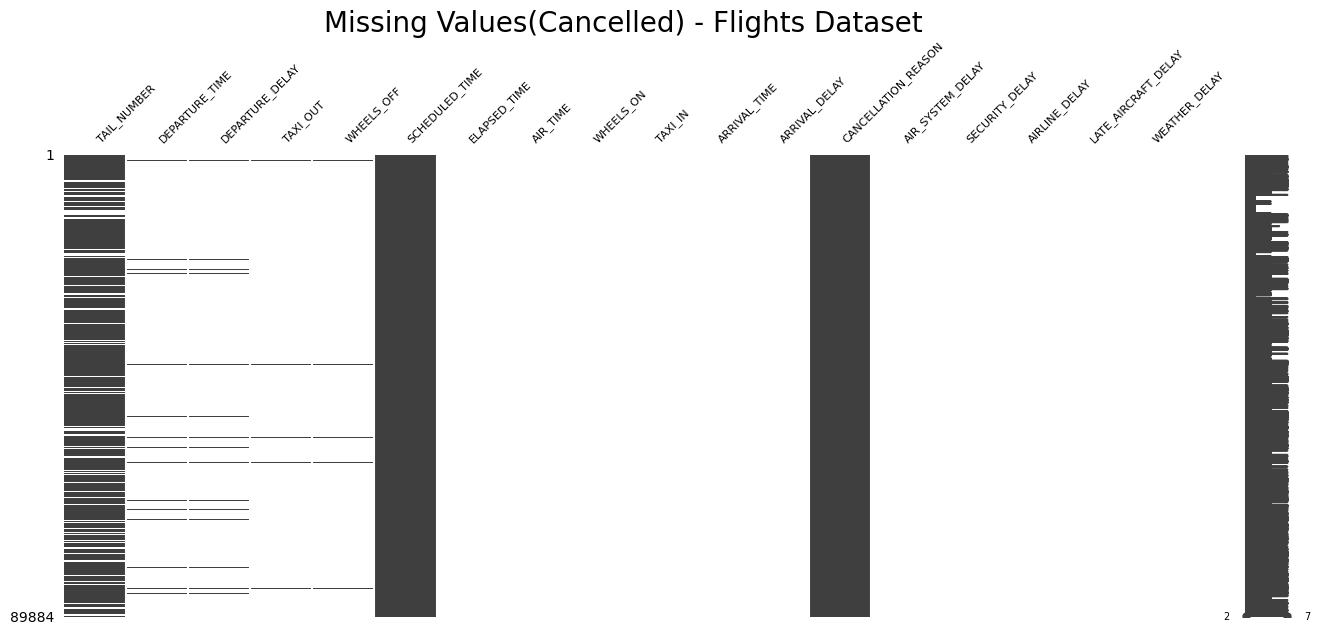

In [64]:
df_cancelled = df_flights[df_flights['CANCELLED'] == 1]
ax = msno.matrix(df_cancelled[cols_nulos], figsize=(16,6), fontsize=8)
ax.get_figure().axes[0].tick_params(axis='x', rotation=45)
plt.title('Missing Values(Cancelled) - Flights Dataset', fontsize=20)
plt.show()

- As colunas relacionadas à operação do voo deveria trazer valores nulos quando o voo é cancelado.
- A coluna CANCELLATION_REASON, por ser categórica, vou transforma-la em variáveis numéricas utilizando encoding.

Irei tratar os dois casos abaixo

In [65]:
cols_operacionais = [
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'WHEELS_OFF'
]

df_flights.loc[
    df_flights['CANCELLED'] == 1,
    cols_operacionais
] = None

In [66]:
# Substituindo valores do motivo do cancelamento
mapping_cancelamento = {'A': 'AIRLINE', 'B': 'WEATHER', 'C': 'NATIONAL AIR SYSTEM', 'D': 'SECURITY'}
df_flights['CANCELLATION_REASON'] = (
    df_flights['CANCELLATION_REASON']
    .map(mapping_cancelamento)
)
# Aplicando o OneHotEncoder para a coluna de motivo de cancelamento
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc = one_hot_encoder.fit_transform(df_flights[['CANCELLATION_REASON']])

encoded_cols = one_hot_encoder.get_feature_names_out(
    ['CANCELLATION_REASON']
)
# DataFrame encoded
df_encoded = pd.DataFrame(
    enc,
    columns=encoded_cols,
    index=df_flights.index
)
df_flights_ajustado = pd.concat([df_flights, df_encoded], axis=1)
df_flights_ajustado.drop(columns=['CANCELLATION_REASON', 'CANCELLATION_REASON_nan'], inplace=True)

### Salvando novo dataframe

In [67]:
df_flights_ajustado.to_csv('../data/processed/flights_ajustado.csv', index=False)

## Juntando as 3 bases

In [76]:
df_airports_origin = df_airports_ajustado.rename(columns={'IATA_CODE': 'IATA_CODE_ORIGIN', 'AIRPORT': 'AIRPORT_ORIGIN', 'CITY': 'CITY_ORIGIN', 'STATE': 'STATE_ORIGIN', 'COUNTRY': 'COUNTRY_ORIGIN', 'LATITUDE': 'LATITUDE_ORIGIN', 'LONGITUDE': 'LONGITUDE_ORIGIN'})
df_airports_dest = df_airports_ajustado.rename(columns={'IATA_CODE': 'IATA_CODE_DESTINATION', 'AIRPORT': 'AIRPORT_DESTINATION', 'CITY': 'CITY_DESTINATION', 'STATE': 'STATE_DESTINATION', 'COUNTRY': 'COUNTRY_DESTINATION', 'LATITUDE': 'LATITUDE_DESTINATION', 'LONGITUDE': 'LONGITUDE_DESTINATION'})
df_airlines = df_airlines.rename(columns={'IATA_CODE': 'IATA_CODE_AIRLINE', 'AIRLINE': 'AIRLINE_NAME'})

df_flights_ajustado['ORIGIN_AIRPORT'] = df_flights_ajustado['ORIGIN_AIRPORT'].astype(str)
df_flights_ajustado['DESTINATION_AIRPORT'] = df_flights_ajustado['DESTINATION_AIRPORT'].astype(str)
df_flights_ajustado['AIRLINE'] = df_flights_ajustado['AIRLINE'].astype(str)

df_airports_origin['IATA_CODE_ORIGIN'] = df_airports_origin['IATA_CODE_ORIGIN'].astype(str)
df_airports_dest['IATA_CODE_DESTINATION'] = df_airports_dest['IATA_CODE_DESTINATION'].astype(str)
df_airlines['IATA_CODE_AIRLINE'] = df_airlines['IATA_CODE_AIRLINE'].astype(str)

In [99]:
df_final = (
    df_flights_ajustado
    .merge(
        df_airports_origin,
        left_on='ORIGIN_AIRPORT',
        right_on='IATA_CODE_ORIGIN',
        how='inner'
    )
    .drop(columns='IATA_CODE_ORIGIN')
    .merge(
        df_airports_dest,
        left_on='DESTINATION_AIRPORT',
        right_on='IATA_CODE_DESTINATION',
        how='inner',
        suffixes=('_ORIGIN', '_DESTINATION')
    )    
    .drop(columns='IATA_CODE_DESTINATION')
    .merge(
        df_airlines,
        left_on='AIRLINE',
        right_on='IATA_CODE_AIRLINE',
        how='left'
    ).drop(columns='IATA_CODE_AIRLINE')
)

In [102]:
df_final.to_parquet('../data/processed/flights.parquet', index=False)